# Complaints Mining — Comparative Clustering Notebook

This notebook implements a **comparative clustering analysis** for the complaints dataset:
- **Text track (NLP):** TF‑IDF + KMeans, and SVD + HDBSCAN (if available)
- **Operational track (categorical):** KModes (if available), Hierarchical clustering with **Gower** distance, and a sklearn baseline (OneHot + KMeans)

It also produces:
- Basic **EDA**
- Cluster **interpretation** (keywords/examples for text, profiles for operational)
- A final **comparison table**

In [2]:
# =========================
# 0) Imports + Settings
# =========================
import os, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_XLSX_PATH = r"Reclamations.xlsx"
assert os.path.exists(DATA_XLSX_PATH), f"File not found: {DATA_XLSX_PATH}"
print("✅ Using dataset:", DATA_XLSX_PATH)

✅ Using dataset: Reclamations.xlsx


In [3]:
# =========================
# 1) Load dataset
# =========================
df = pd.read_excel(DATA_XLSX_PATH, sheet_name=0)

# Type fixes
df["date"] = pd.to_datetime(df["date"], errors="coerce")
for c in ["wilaya","canal","categorie","sentiment","urgence","status","suggested_action"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Derived time features
df["month"] = df["date"].dt.to_period("M").astype(str)
df["weekday"] = df["date"].dt.day_name()

print("Shape:", df.shape)
display(df.head())

Shape: (100000, 12)


,id,date,wilaya,canal,texte_reclamation,categorie,sentiment,urgence,status,suggested_action,month,weekday
0,105001,2024-07-31,Tizi Ouzou,Centre d'appel,Incident: modem ne se synchronise pas.,Coupure de ligne,Négatif,Moyenne,Résolu,Redémarrage du modem,2024-07,Wednesday
1,105002,2024-10-29,Boumerdès,Application mobile,Client signale problème lors de la résiliation...,Résiliation,Négatif,Moyenne,En cours,Vérifier décodeur,2024-10,Tuesday
2,105003,2024-03-22,Msila,Site web,Demande d'assistance: bruit important sur la l...,Coupure de ligne,Négatif,Basse,Résolu,Envoi technicien,2024-03,Friday
3,105004,2024-04-15,Saïda,Centre d'appel,"Incident: problème lors de la résiliation, fac...",Coupure de ligne,Négatif,Moyenne,Nouveau,Vérifier décodeur,2024-04,Monday
4,105005,2025-09-04,Boumerdès,Site web,Incident: installation non réalisée dans les d...,Coupure de ligne,Négatif,Basse,Clôturé,Vérifier décodeur,2025-09,Thursday


In [4]:
# =========================
# 2) Quick data checks
# =========================
display(df.dtypes)

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

uniques = df.nunique().sort_values(ascending=False)
display(uniques)

print("Unique texte_reclamation:", df["texte_reclamation"].nunique())

id                            int64
date                 datetime64[ns]
wilaya                       object
canal                        object
texte_reclamation            object
categorie                    object
sentiment                    object
urgence                      object
status                       object
suggested_action             object
month                        object
weekday                      object
dtype: object

Series([], dtype: int64)

id                   100000
date                    659
texte_reclamation        50
wilaya                   27
month                    22
categorie                10
suggested_action          8
weekday                   7
canal                     5
status                    5
urgence                   4
sentiment                 3
dtype: int64

Unique texte_reclamation: 50


## 3) EDA (basic)

These are quick plots/tables. Feel free to add more.

,count
categorie,
Coupure de ligne,22375
Internet lent,20034
Facturation,11891
Télévision,10021
Installation,9871
Assistance,7908
Résiliation,6101
Problème matériel,5879
Configuration,3954


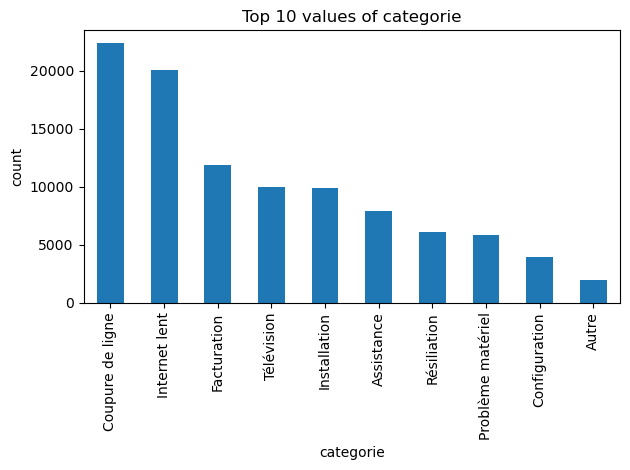

,count
wilaya,
Jijel,3832
Laghouat,3814
Annaba,3778
Batna,3757
Oran,3751
Biskra,3749
Tizi Ouzou,3749
Béjaïa,3743
Blida,3740


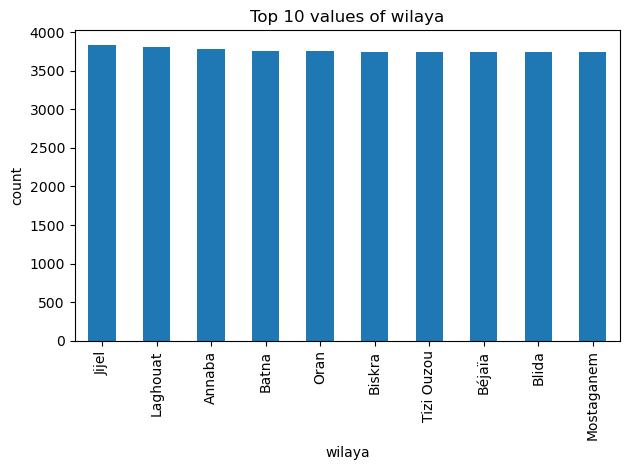

,count
canal,
Centre d'appel,39649
Site web,20085
Agence commerciale,15206
Application mobile,15025
Email,10035


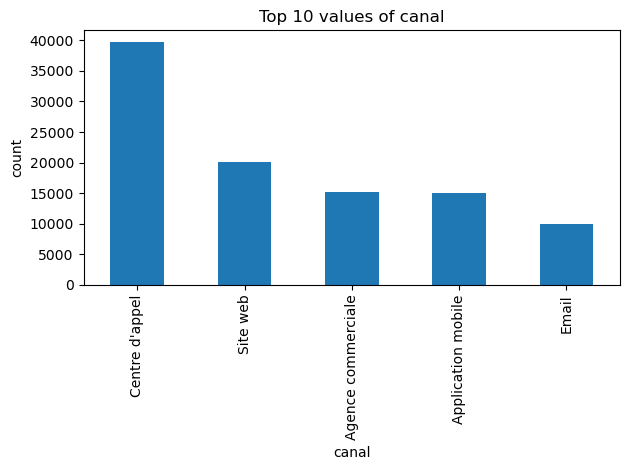

,count
urgence,
Moyenne,40136
Basse,39839
élevée,15131
Critique,4894


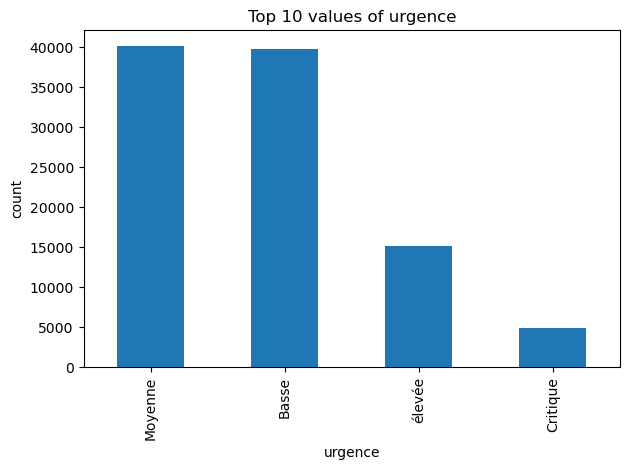

,count
status,
Résolu,35003
En cours,29960
Nouveau,25005
Escaladé,5072
Clôturé,4960


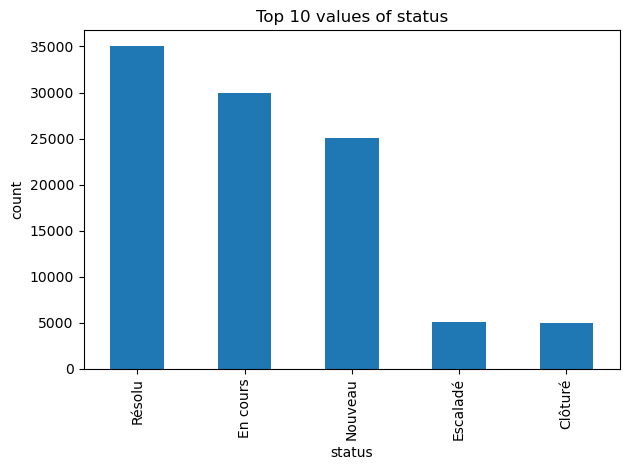

,count
sentiment,
Négatif,60167
Neutre,29883
Positif,9950


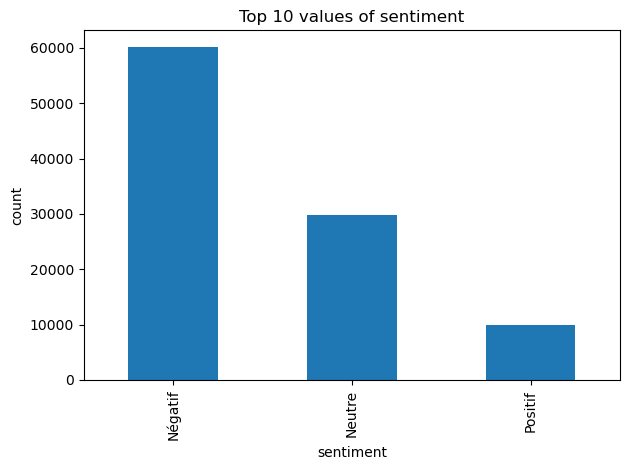

In [5]:
def show_top_counts(df, col, top=10):
    vc = df[col].value_counts().head(top)
    display(vc.to_frame("count"))
    plt.figure()
    vc.plot(kind="bar")
    plt.title(f"Top {top} values of {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

for col in ["categorie","wilaya","canal","urgence","status","sentiment"]:
    show_top_counts(df, col, top=10)

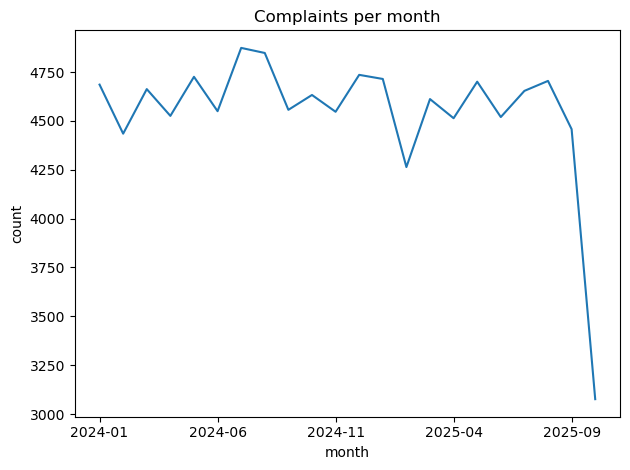

In [6]:
# Complaints over time (monthly)
month_counts = df["month"].value_counts().sort_index()
plt.figure()
month_counts.plot(kind="line")
plt.title("Complaints per month")
plt.xlabel("month")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 4) Text preprocessing

In [7]:
# Minimal French stopwords list (extend if needed)
FR_STOP = set("""
a au aux avec ce ces dans de des du elle en et eux il je la le les leur lui ma mais me meme mes moi mon ne nos notre nous on ou par pas
pour qu que qui sa se ses son sur ta te tes toi ton tu un une vos votre vous c est d l y s
""".split())

def clean_text_fr(text: str) -> str:
    if pd.isna(text):
        return ""
    t = str(text).lower()
    t = re.sub(r"[’']", " ", t)
    t = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", t)  # keep letters + spaces
    t = re.sub(r"\s+", " ", t).strip()
    tokens = [w for w in t.split() if w not in FR_STOP and len(w) > 2]
    return " ".join(tokens)

df["text_clean"] = df["texte_reclamation"].apply(clean_text_fr)
display(df[["texte_reclamation","text_clean"]].head(10))

,texte_reclamation,text_clean
0,Incident: modem ne se synchronise pas.,incident modem synchronise
1,Client signale problème lors de la résiliation...,client signale problème lors résiliation factu...
2,Demande d'assistance: bruit important sur la l...,demande assistance bruit important ligne télép...
3,"Incident: problème lors de la résiliation, fac...",incident problème lors résiliation facturation...
4,Incident: installation non réalisée dans les d...,incident installation non réalisée délais
5,Demande d'assistance: image figée sur certaine...,demande assistance image figée certaines chaines
6,Demande d'assistance: montant facturé incorrec...,demande assistance montant facturé incorrectem...
7,"Réclamation: montant facturé incorrectement, d...",réclamation montant facturé incorrectement dem...
8,Client signale demande d'information sur l'off...,client signale demande information offre contrat
9,Réclamation: erreur d'authentification lors de...,réclamation erreur authentification lors conne...


In [8]:
# Keyword extraction (overall)
vec = CountVectorizer(ngram_range=(1,2), min_df=10)
X_counts = vec.fit_transform(df["text_clean"])
terms = np.array(vec.get_feature_names_out())
freq = np.asarray(X_counts.sum(axis=0)).ravel()

top_idx = freq.argsort()[::-1][:25]
keywords = pd.DataFrame({"term": terms[top_idx], "freq": freq[top_idx]})
display(keywords)

,term,freq
0,demande,39854
1,réclamation,20145
2,client,20076
3,signale,20076
4,client signale,20076
5,rapporte,19997
6,abonné,19997
7,abonné rapporte,19997
8,incident,19927
9,lors,19905


## 5) Sampling strategy for fair comparison

- **Text track** can handle bigger samples (TF‑IDF sparse vectors).
- **Gower + hierarchical** is **O(n²)** → use smaller samples.

In [9]:
N_TEXT = 30000   # ok for TF-IDF + KMeans
N_GOWER = 7000   # keep small for Gower + hierarchical
df_text = df.sample(min(N_TEXT, len(df)), random_state=RANDOM_SEED).copy()
df_gower = df.sample(min(N_GOWER, len(df)), random_state=RANDOM_SEED).copy()

print("Text sample:", df_text.shape)
print("Gower sample:", df_gower.shape)

Text sample: (30000, 13)
Gower sample: (7000, 13)


# A) Text clustering track (NLP)

We compare:
- **TF‑IDF + KMeans** (baseline, needs k)
- **SVD + HDBSCAN** (if `hdbscan` installed), no need k, can mark noise/outliers

In [10]:
# =========================
# A1) TF-IDF matrix on text sample
# =========================
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)
X_tfidf = tfidf.fit_transform(df_text["text_clean"])
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (30000, 128)


k=3 silhouette=0.1236
k=4 silhouette=0.1544
k=5 silhouette=0.1729
k=6 silhouette=0.2528
k=7 silhouette=0.2994
k=8 silhouette=0.3648
k=9 silhouette=0.4710
k=10 silhouette=0.5166
k=11 silhouette=0.5117
k=12 silhouette=0.4964


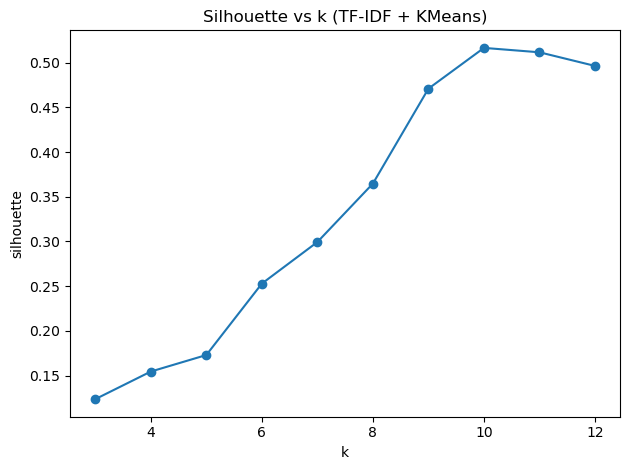

Chosen k: 10


In [11]:
# =========================
# A2) Choose k for KMeans via silhouette
# =========================
ks = list(range(3, 13))
scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    labels = km.fit_predict(X_tfidf)
    sil = silhouette_score(X_tfidf, labels)
    scores.append(sil)
    print(f"k={k} silhouette={sil:.4f}")

plt.figure()
plt.plot(ks, scores, marker="o")
plt.title("Silhouette vs k (TF-IDF + KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.tight_layout()
plt.show()

BEST_K = int(ks[int(np.argmax(scores))])
print("Chosen k:", BEST_K)

In [12]:
# =========================
# A3) Fit final TF-IDF + KMeans and interpret clusters
# =========================
kmeans_text = KMeans(n_clusters=BEST_K, random_state=RANDOM_SEED, n_init="auto")
df_text["cluster_tfidf_kmeans"] = kmeans_text.fit_predict(X_tfidf)

# Top terms per cluster
feature_names = np.array(tfidf.get_feature_names_out())
centroids = kmeans_text.cluster_centers_

def top_terms_for_cluster(cluster_id, topn=10):
    idx = centroids[cluster_id].argsort()[::-1][:topn]
    return feature_names[idx].tolist()

summary = []
for cid in range(BEST_K):
    part = df_text[df_text["cluster_tfidf_kmeans"] == cid]
    summary.append({
        "cluster": cid,
        "n": len(part),
        "top_terms": ", ".join(top_terms_for_cluster(cid, 10)),
        "examples": " | ".join(part["texte_reclamation"].head(3).tolist())
    })

display(pd.DataFrame(summary).sort_values("n", ascending=False))

,cluster,n,top_terms,examples
1,1,3069,"téléphonique, bruit important, ligne téléphoni...",Réclamation: bruit important sur la ligne télé...
7,7,3052,"très, soirée, très faible, faible soirée, faib...",Réclamation: débit très faible en soirée. | Cl...
0,0,3041,"certaines chaines, figée, chaines, certaines, ...",Incident: image figée sur certaines chaines. |...
5,5,3040,"montant facturé, facturé incorrectement, incor...","Client signale montant facturé incorrectement,..."
8,8,2999,"synchronise, modem, modem synchronise, réclama...",Client signale modem ne se synchronise pas. | ...
6,6,2981,"depuis, matin, coupure, depuis matin, service,...",Abonné rapporte coupure de service depuis ce m...
2,2,2980,"problème lors, lors résiliation, résiliation, ...",Demande d'assistance: problème lors de la rési...
3,3,2971,"installation, installation non, non, non réali...",Demande d'assistance: installation non réalisé...
4,4,2941,"information, contrat, demande information, inf...",Demande d'assistance: demande d'information su...
9,9,2926,"erreur authentification, connexion, authentifi...",Demande d'assistance: erreur d'authentificatio...


In [13]:
# =========================
# A4) SVD + HDBSCAN (optional; if package is available)
# =========================
X_svd = TruncatedSVD(n_components=50, random_state=RANDOM_SEED).fit_transform(X_tfidf)
print("SVD shape:", X_svd.shape)

try:
    import hdbscan
    hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
    df_text["cluster_hdbscan"] = hdb.fit_predict(X_svd)

    counts = df_text["cluster_hdbscan"].value_counts()
    print("HDBSCAN cluster counts (includes -1 = noise):")
    display(counts.head(20))
except Exception as e:
    print("⚠️ HDBSCAN not available in this environment:", e)
    df_text["cluster_hdbscan"] = np.nan

SVD shape: (30000, 50)
HDBSCAN cluster counts (includes -1 = noise):


cluster_hdbscan
38    652
8     639
44    634
18    633
37    630
23    622
4     622
13    619
42    618
49    617
34    616
5     615
46    614
30    609
22    609
1     609
24    608
19    607
12    606
35    605
Name: count, dtype: int64

# B) Operational clustering track (categorical)

We compare:
- **KModes** (if installed)
- **Hierarchical + Gower distance** (categorical-friendly)
- A sklearn baseline: **OneHot + KMeans**

In [14]:
CAT_FEATURES = ["wilaya","canal","categorie","sentiment","urgence","status"]
X_cat_g = df_gower[CAT_FEATURES].copy()
display(X_cat_g.head())

,wilaya,canal,categorie,sentiment,urgence,status
75721,Béjaïa,Site web,Installation,Négatif,Basse,Clôturé
80184,Msila,Site web,Internet lent,Négatif,Moyenne,En cours
19864,Tiaret,Site web,Assistance,Neutre,Basse,En cours
76699,Boumerdès,Email,Coupure de ligne,Neutre,élevée,Nouveau
92991,Batna,Centre d'appel,Internet lent,Négatif,Basse,Résolu


k=3 silhouette=0.0710
k=4 silhouette=0.0632
k=5 silhouette=0.0766
k=6 silhouette=0.0647
k=7 silhouette=0.0511
k=8 silhouette=0.0760
k=9 silhouette=0.0703
k=10 silhouette=0.0708


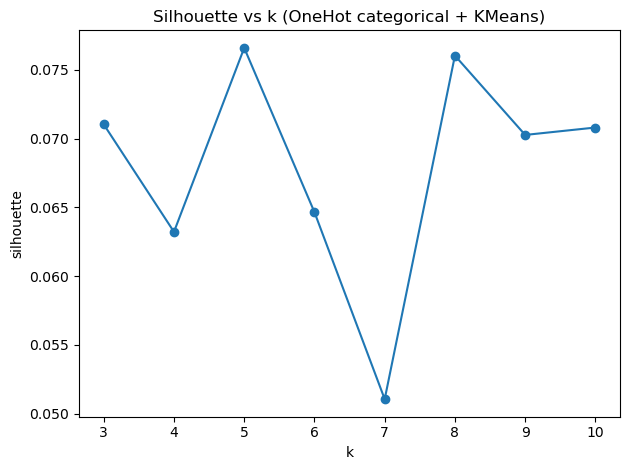

Chosen k: 5


cluster_ohe_kmeans
1    2090
2    1474
4    1401
0    1352
3     683
Name: count, dtype: int64

In [15]:
# =========================
# B1) Baseline: OneHot + KMeans (sklearn-only)
# =========================
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_ohe = ohe.fit_transform(X_cat_g)

ks_op = list(range(3, 11))
scores_op = []
for k in ks_op:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    labels = km.fit_predict(X_ohe)
    sil = silhouette_score(X_ohe, labels)
    scores_op.append(sil)
    print(f"k={k} silhouette={sil:.4f}")

plt.figure()
plt.plot(ks_op, scores_op, marker="o")
plt.title("Silhouette vs k (OneHot categorical + KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.tight_layout()
plt.show()

BEST_K_OP = int(ks_op[int(np.argmax(scores_op))])
print("Chosen k:", BEST_K_OP)

kmeans_op = KMeans(n_clusters=BEST_K_OP, random_state=RANDOM_SEED, n_init="auto")
df_gower["cluster_ohe_kmeans"] = kmeans_op.fit_predict(X_ohe)
display(df_gower["cluster_ohe_kmeans"].value_counts())

In [20]:
%pip install kmodes

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


k=3 cost=23105.00
k=4 cost=22201.00
k=5 cost=21371.00
k=6 cost=20935.00
k=7 cost=20683.00
k=8 cost=20177.00
k=9 cost=19973.00
k=10 cost=19711.00


,k,cost
0,3,23105.0
1,4,22201.0
2,5,21371.0
3,6,20935.0
4,7,20683.0
5,8,20177.0
6,9,19973.0
7,10,19711.0


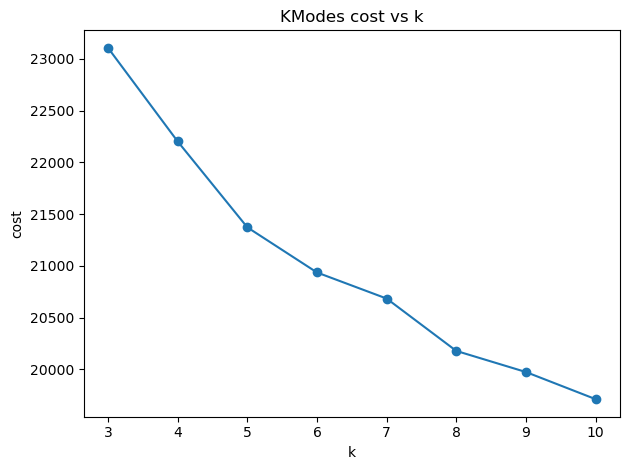

Chosen k for KModes (default=min cost): 10


cluster_kmodes
1    1338
2    1209
0    1156
3     860
8     590
5     548
4     482
6     330
9     282
7     205
Name: count, dtype: int64

In [21]:
# =========================
# B2) KModes (optional)
# =========================

try:
    from kmodes.kmodes import KModes

    kmodes_results = []
    for k in range(3, 11):
        model = KModes(n_clusters=k, init="Huang", n_init=5, verbose=0, random_state=RANDOM_SEED)
        labels = model.fit_predict(X_cat_g)
        kmodes_results.append({"k": k, "cost": model.cost_})
        print(f"k={k} cost={model.cost_:.2f}")

    kmodes_results = pd.DataFrame(kmodes_results)
    display(kmodes_results)

    plt.figure()
    plt.plot(kmodes_results["k"], kmodes_results["cost"], marker="o")
    plt.title("KModes cost vs k")
    plt.xlabel("k")
    plt.ylabel("cost")
    plt.tight_layout()
    plt.show()

    # Choose k with an elbow; here we pick the minimum cost as a simple default
    BEST_K_KMODES = int(kmodes_results.sort_values("cost").iloc[0]["k"])
    print("Chosen k for KModes (default=min cost):", BEST_K_KMODES)

    kmodes_final = KModes(n_clusters=BEST_K_KMODES, init="Huang", n_init=10, verbose=0, random_state=RANDOM_SEED)
    df_gower["cluster_kmodes"] = kmodes_final.fit_predict(X_cat_g)

    display(df_gower["cluster_kmodes"].value_counts())
except Exception as e:
    print("⚠️ kmodes not available in this environment:", e)
    df_gower["cluster_kmodes"] = np.nan

In [22]:
# =========================
# B3) Hierarchical clustering with categorical Gower distance
# =========================
def gower_distance_categorical(df_cat: pd.DataFrame) -> np.ndarray:
    """Gower distance for categorical-only features:
    distance(i,j) = mean(feature_mismatch)
    returns NxN distance matrix (float32).
    """
    X = df_cat.astype(str).to_numpy()
    n, m = X.shape
    D = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        mismatch = (X[i] != X).mean(axis=1).astype(np.float32)
        D[i, :] = mismatch
    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    return D

D = gower_distance_categorical(X_cat_g)
print("Gower distance matrix:", D.shape, "min/max:", float(D.min()), float(D.max()))

condensed = squareform(D, checks=False)
Z = linkage(condensed, method="average")

K_HIER = 6  # you can tune this (try 3..10)
labels_hier = fcluster(Z, t=K_HIER, criterion="maxclust")
df_gower["cluster_hier_gower"] = labels_hier

display(df_gower["cluster_hier_gower"].value_counts())

Gower distance matrix: (7000, 7000) min/max: 0.0 1.0


cluster_hier_gower
5    3482
2    1701
3     759
1     620
4     239
6     199
Name: count, dtype: int64

In [23]:
# =========================
# B4) Operational cluster profiling (same for each algorithm)
# =========================
def profile_clusters(df_s, label_col, topn=5):
    out = []
    labels = pd.Series(df_s[label_col]).dropna().unique()
    for cid in sorted(labels):
        part = df_s[df_s[label_col] == cid]
        out.append({
            "cluster": cid,
            "n": len(part),
            "pct": round(100*len(part)/len(df_s), 2),
            "top_wilaya": ", ".join(part["wilaya"].value_counts().head(topn).index.astype(str)),
            "top_canal": ", ".join(part["canal"].value_counts().head(topn).index.astype(str)),
            "top_categorie": ", ".join(part["categorie"].value_counts().head(topn).index.astype(str)),
            "%critique": round(100*(part["urgence"].str.lower()=="critique").mean(), 2),
            "%elevee": round(100*(part["urgence"].str.lower()=="élevée").mean(), 2),
            "%escalade": round(100*(part["status"].str.lower()=="escaladé").mean(), 2),
            "%resolu": round(100*(part["status"].str.lower()=="résolu").mean(), 2),
        })
    return pd.DataFrame(out).sort_values("n", ascending=False)

print("== OneHot + KMeans profiles ==")
display(profile_clusters(df_gower, "cluster_ohe_kmeans"))

if df_gower["cluster_kmodes"].notna().any():
    print("== KModes profiles ==")
    display(profile_clusters(df_gower, "cluster_kmodes"))

print("== Hierarchical + Gower profiles ==")
display(profile_clusters(df_gower, "cluster_hier_gower"))

== OneHot + KMeans profiles ==


,cluster,n,pct,top_wilaya,top_canal,top_categorie,%critique,%elevee,%escalade,%resolu
1,1,2090,29.86,"Batna, Laghouat, Annaba, Skikda, Sidi Bel Abbès","Centre d'appel, Site web, Agence commerciale, ...","Coupure de ligne, Internet lent, Facturation, ...",5.22,15.45,4.83,35.60
2,2,1474,21.06,"Médéa, Jijel, Relizane, Annaba, El Oued","Centre d'appel, Site web, Agence commerciale, ...","Coupure de ligne, Internet lent, Facturation, ...",5.16,15.94,0.00,0.00
4,4,1401,20.01,"Laghouat, Batna, Relizane, Msila, Ghardaïa","Centre d'appel, Site web, Agence commerciale, ...","Coupure de ligne, Internet lent, Facturation, ...",0.00,0.00,7.14,51.82
0,0,1352,19.31,"Jijel, Sidi Bel Abbès, Biskra, Mostaganem, Skikda","Centre d'appel, Site web, Application mobile, ...","Coupure de ligne, Internet lent, Facturation, ...",0.00,0.00,7.40,50.44
3,3,683,9.76,"Béjaïa, Biskra, Relizane, Mostaganem, Adrar","Centre d'appel, Site web, Agence commerciale, ...","Coupure de ligne, Internet lent, Facturation, ...",26.79,73.21,7.91,47.14


== KModes profiles ==


,cluster,n,pct,top_wilaya,top_canal,top_categorie,%critique,%elevee,%escalade,%resolu
1,1,1338,19.11,"Laghouat, Tlemcen, Boumerdès, Relizane, Médéa","Site web, Centre d'appel, Application mobile, ...","Internet lent, Facturation, Installation, Coup...",4.56,9.64,5.46,17.56
2,2,1209,17.27,"Constantine, Sétif, Batna, Skikda, Tlemcen","Centre d'appel, Application mobile, Agence com...","Coupure de ligne, Facturation, Installation, A...",6.04,15.72,6.78,76.43
0,0,1156,16.51,"Saïda, El Oued, Relizane, Jijel, Biskra","Agence commerciale, Centre d'appel, Site web, ...","Télévision, Coupure de ligne, Facturation, Ins...",6.14,13.84,4.58,11.68
3,3,860,12.29,"Saïda, Tizi Ouzou, Oran, Mostaganem, Skikda","Centre d'appel, Site web, Application mobile, ...","Coupure de ligne, Internet lent, Facturation, ...",1.05,1.63,5.35,57.09
8,8,590,8.43,"Msila, Tiaret, Blida, El Oued, Mostaganem","Centre d'appel, Application mobile, Email, Age...","Coupure de ligne, Facturation, Internet lent, ...",6.10,13.39,1.36,0.00
5,5,548,7.83,"Adrar, Boumerdès, Médéa, Alger, Relizane","Centre d'appel, Application mobile, Site web, ...","Internet lent, Facturation, Installation, Assi...",7.12,18.80,4.38,45.62
4,4,482,6.89,"Sidi Bel Abbès, Relizane, Skikda, Sétif, El Oued","Agence commerciale, Site web, Application mobi...","Télévision, Facturation, Installation, Assista...",7.68,15.15,6.22,58.92
6,6,330,4.71,"Laghouat, Mostaganem, Jijel, Blida, Béjaïa","Application mobile, Centre d'appel, Email, Age...","Internet lent, Coupure de ligne, Facturation, ...",8.18,19.09,6.06,6.06
9,9,282,4.03,"Annaba, Médéa, Batna, Tizi Ouzou, El Oued","Site web, Email, Agence commerciale, Applicati...","Télévision, Facturation, Assistance, Résiliati...",3.19,73.76,3.55,12.06
7,7,205,2.93,"Sidi Bel Abbès, Ghardaïa, Jijel, Ouargla, Médéa","Centre d'appel, Site web, Application mobile, ...","Coupure de ligne, Assistance, Facturation, Ins...",2.93,19.02,4.39,49.27


== Hierarchical + Gower profiles ==


,cluster,n,pct,top_wilaya,top_canal,top_categorie,%critique,%elevee,%escalade,%resolu
4,5,3482,49.74,"Laghouat, Tlemcen, Relizane, Adrar, Médéa","Centre d'appel, Site web, Agence commerciale, ...","Coupure de ligne, Internet lent, Facturation, ...",1.29,3.39,1.67,35.99
1,2,1701,24.30,"Batna, Annaba, Skikda, Laghouat, Sétif","Centre d'appel, Site web, Agence commerciale, ...","Coupure de ligne, Internet lent, Facturation, ...",2.94,5.53,3.12,37.98
2,3,759,10.84,"Msila, Relizane, Béjaïa, Médéa, Ghardaïa","Centre d'appel, Site web, Application mobile, ...","Coupure de ligne, Internet lent, Facturation, ...",1.32,96.18,2.90,33.73
0,1,620,8.86,"Saïda, Oran, Blida, Batna, Sétif","Centre d'appel, Site web, Agence commerciale, ...","Internet lent, Coupure de ligne, Facturation, ...",3.87,13.23,2.26,38.39
3,4,239,3.41,"Adrar, Blida, Mostaganem, Skikda, Msila","Centre d'appel, Site web, Agence commerciale, ...","Coupure de ligne, Internet lent, Télévision, F...",99.16,0.84,4.60,33.89
5,6,199,2.84,"Msila, Laghouat, Ouargla, Mostaganem, Annaba","Centre d'appel, Agence commerciale, Site web, ...","Coupure de ligne, Internet lent, Télévision, R...",1.01,16.08,98.99,0.00


# C) Comparative metrics table

Notes:
- **Silhouette** is used for vector spaces (TF‑IDF, OneHot).  
- For **Gower hierarchical**, we compute silhouette with `metric="precomputed"`.
- HDBSCAN returns **noise** label `-1`.

In [24]:
results = []

# Text: TF-IDF + KMeans
labels = df_text["cluster_tfidf_kmeans"].values
results.append({
    "track": "text",
    "algo": "TFIDF_KMEANS",
    "n_samples": len(df_text),
    "n_clusters": int(len(np.unique(labels))),
    "silhouette": float(silhouette_score(X_tfidf, labels)),
    "noise_pct": 0.0
})

# Text: HDBSCAN (if available)
if df_text["cluster_hdbscan"].notna().any():
    labels_h = df_text["cluster_hdbscan"].values
    noise_pct = float((labels_h == -1).mean() * 100)
    n_clusters = len(set(labels_h)) - (1 if -1 in labels_h else 0)
    results.append({
        "track": "text",
        "algo": "SVD_HDBSCAN",
        "n_samples": len(df_text),
        "n_clusters": int(n_clusters),
        "silhouette": np.nan,  # optional: compute on non-noise only
        "noise_pct": noise_pct
    })

# Operational: OneHot + KMeans
labels_op = df_gower["cluster_ohe_kmeans"].values
results.append({
    "track": "operational",
    "algo": "OHE_KMEANS",
    "n_samples": len(df_gower),
    "n_clusters": int(len(np.unique(labels_op))),
    "silhouette": float(silhouette_score(X_ohe, labels_op)),
    "noise_pct": 0.0
})

# Operational: KModes (if available)
if df_gower["cluster_kmodes"].notna().any():
    labels_km = df_gower["cluster_kmodes"].values
    results.append({
        "track": "operational",
        "algo": "KMODES",
        "n_samples": len(df_gower),
        "n_clusters": int(len(np.unique(labels_km))),
        "silhouette": np.nan,   # silhouette not directly comparable for KModes
        "noise_pct": 0.0
    })

# Operational: Hier + Gower silhouette (precomputed)
try:
    from sklearn.metrics import silhouette_score as sil
    labels_hg = df_gower["cluster_hier_gower"].values
    sil_g = sil(D, labels_hg, metric="precomputed")
except Exception:
    sil_g = np.nan

results.append({
    "track": "operational",
    "algo": "HIER_GOWER",
    "n_samples": len(df_gower),
    "n_clusters": int(len(np.unique(df_gower["cluster_hier_gower"].values))),
    "silhouette": float(sil_g) if not np.isnan(sil_g) else np.nan,
    "noise_pct": 0.0
})

comparison = pd.DataFrame(results).sort_values(["track","algo"])
display(comparison)

,track,algo,n_samples,n_clusters,silhouette,noise_pct
4,operational,HIER_GOWER,7000,6,0.120934,0.0
3,operational,KMODES,7000,10,NaN,0.0
2,operational,OHE_KMEANS,7000,5,0.076591,0.0
1,text,SVD_HDBSCAN,30000,50,NaN,0.0
0,text,TFIDF_KMEANS,30000,10,0.516575,0.0


## 8) Optional: Export labeled sample results

You can export:
- `df_text` with text clusters
- `df_gower` with operational clusters

In [ ]:
OUT_TEXT = "complaints_text_clusters_sample.xlsx"
OUT_OP   = "complaints_operational_clusters_sample.xlsx"

df_text.to_excel(OUT_TEXT, index=False)
df_gower.to_excel(OUT_OP, index=False)

print("✅ Saved:", OUT_TEXT)
print("✅ Saved:", OUT_OP)